In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles


In [12]:
np.random.seed(13)
X,y=make_circles(n_samples=500,factor=0.1,noise=0.35,random_state=13)

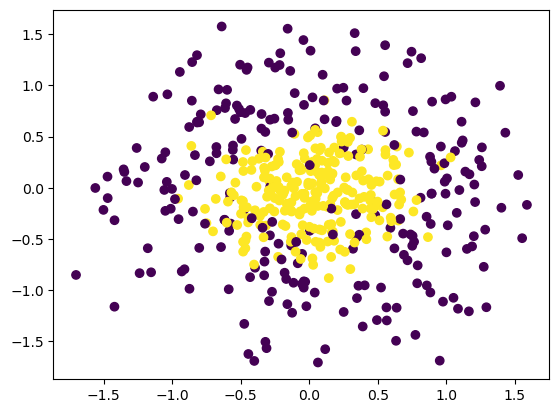

In [13]:
plt.scatter(X[:,0],X[:,1],c=y)


In [14]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score

abc=AdaBoostClassifier()

np.mean(cross_val_score(abc,X,y,scoring='accuracy',cv=10))

np.float64(0.858)

<Axes: >

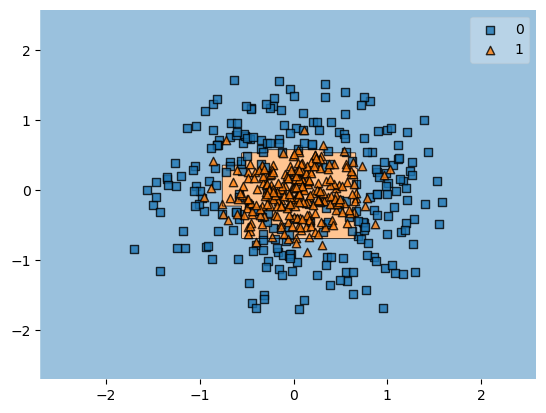

In [17]:
abc.fit(X,y)
plot_decision_regions(X,y,abc)

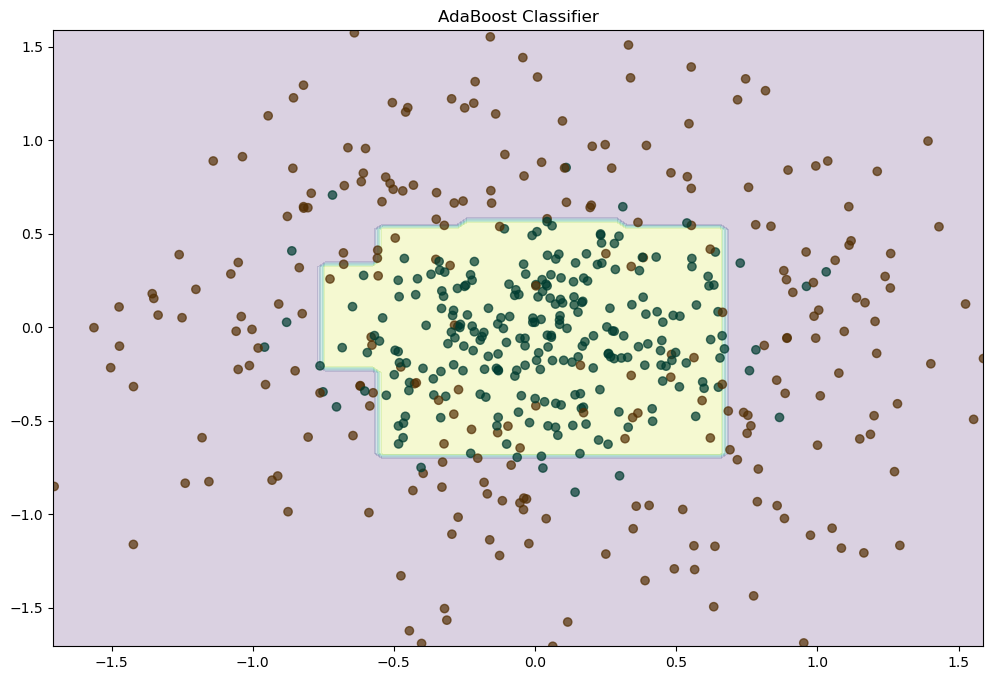

In [20]:
def plot_decision_boundary(clf):
    plt.figure(figsize=(12,8))
    x_range=np.linspace(X.min(),X.max(),100)
    xx1, xx2= np.meshgrid(x_range, x_range)
    y_hat=clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
    y_hat= y_hat.reshape(xx1.shape)
    plt.contourf(xx1,xx2,y_hat,alpha=0.2)
    plt.scatter(X[:,0],X[:,1],c=y, cmap='BrBG',alpha=0.7)
    plt.title("AdaBoost Classifier")
    plt.show()

plot_decision_boundary(abc)


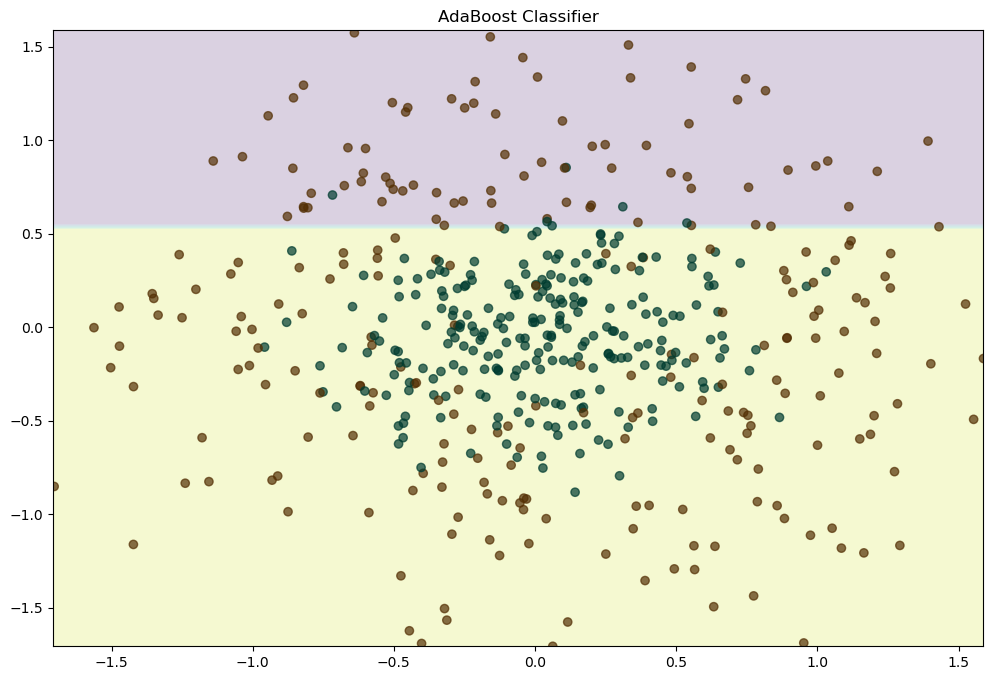

In [21]:
abc=AdaBoostClassifier(n_estimators=1)
abc.fit(X,y)
plot_decision_boundary(abc)


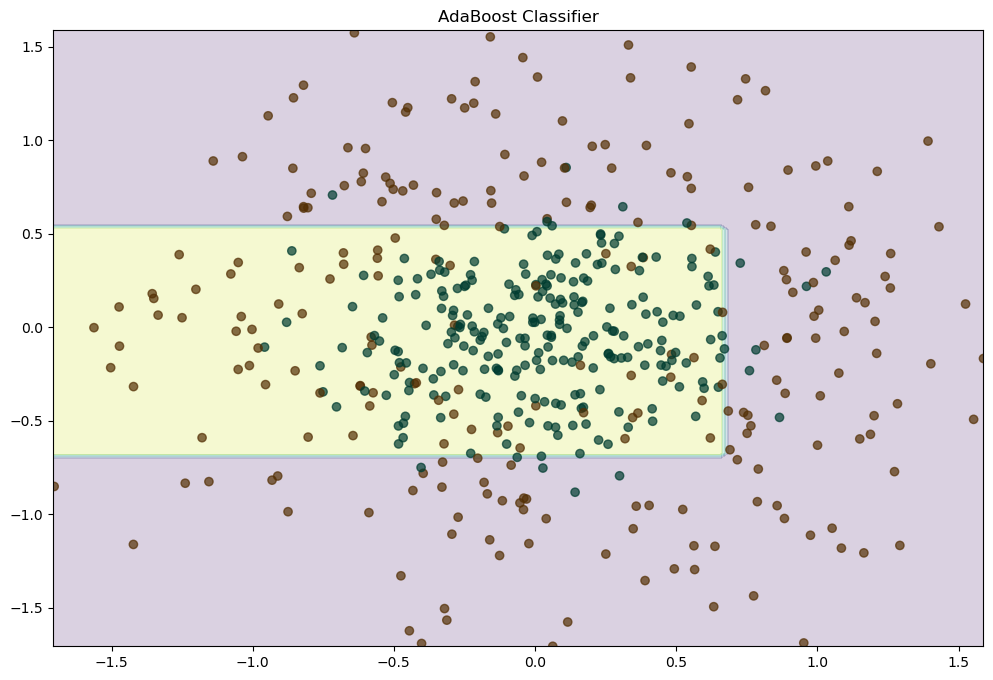

In [23]:
abc=AdaBoostClassifier(n_estimators=5)
abc.fit(X,y)
plot_decision_boundary(abc)


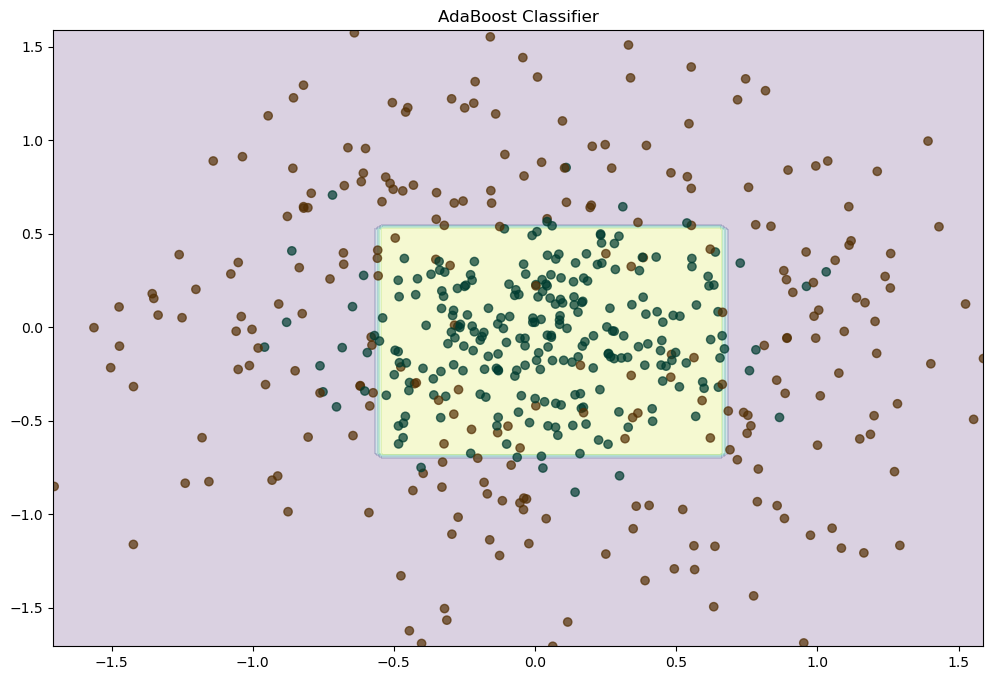

In [24]:
abc=AdaBoostClassifier(n_estimators=8)
abc.fit(X,y)
plot_decision_boundary(abc)


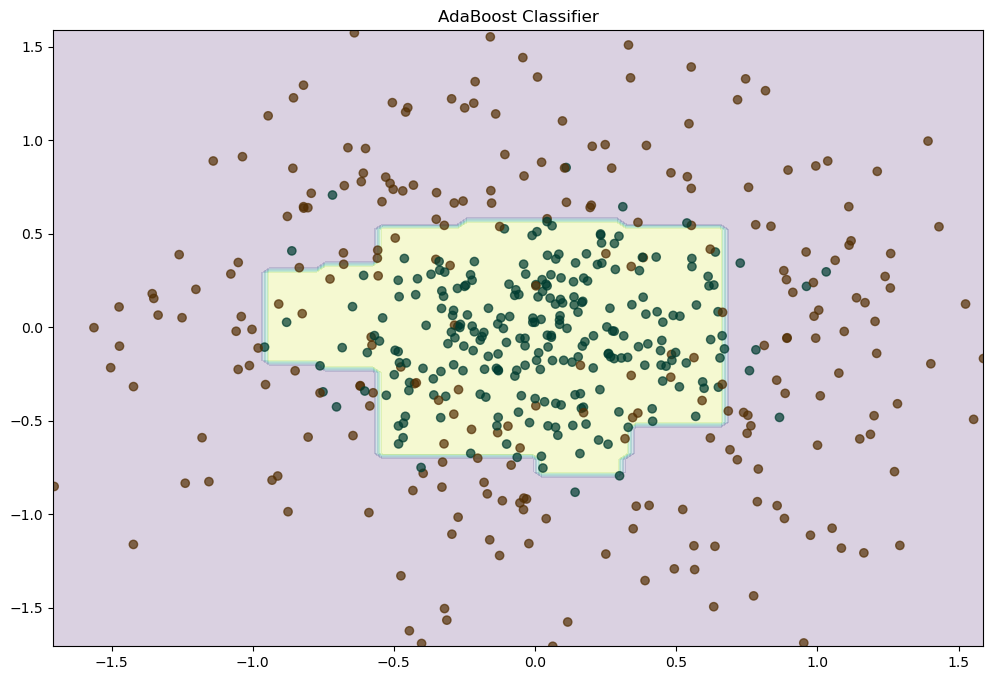

In [25]:
abc=AdaBoostClassifier(n_estimators=150)
abc.fit(X,y)
plot_decision_boundary(abc)


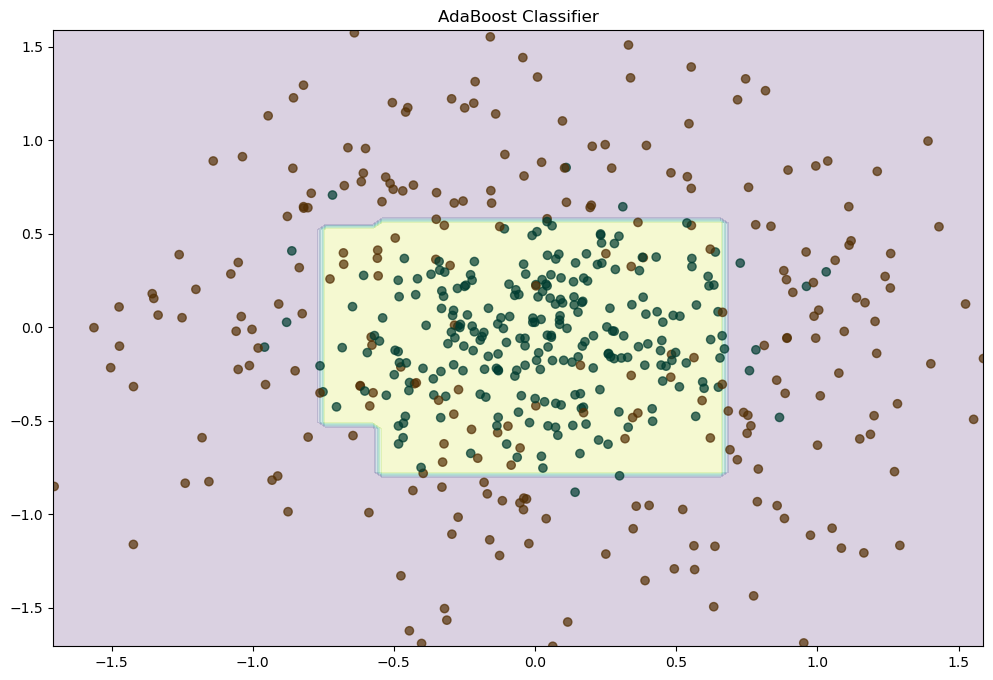

In [27]:
abc=AdaBoostClassifier(n_estimators=500,learning_rate=0.1)
abc.fit(X,y)
plot_decision_boundary(abc)


## it Starts overfitting so we are now applying hyperparameter tuning.....

In [ ]:
from sklearn.model_selection import GridSearchCV

grid={"n_estimators":[10,50,100,500],
      'learning_rate': [0.0001,0.001,0.01,0.1,1.0]
      }

grid_search=GridSearchCV(estimator=AdaBoostClassifier(),param_grid=grid, n_jobs=-1, cv=10, scoring='accuracy')

grid_result=grid_search.fit(X,y)



In [32]:
print("Best: %f using %s " % (grid_result.best_score_, grid_result.best_params_))

Best: 0.868000 using {'learning_rate': 1.0, 'n_estimators': 500} 
